## Food recommendation based on grouping of foods with similar nutrient contents
Selected model = k-means - cluster numerical data (nutrients)

In [1]:
# libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
import pickle as pkl

proj_dir = "D:/r/KenyaDSM"
foods_path = proj_dir + '/' + "data/foods"

### Prepare data

In [2]:
foods = pd.read_csv(foods_path + '/' + 'veg_k_mg.csv')
foods.tail()

,Code,Vegetable,Magnesium,Potassium
91,4097,"Tomato, green, boiled, drained (without salt)",10.0,144.0
92,4036,"Tomato, red, ripe, raw",9.5,126.0
93,4098,"Tomato, red, ripe, boiled, drained (without salt)",7.0,81.0
94,4038,"Vine (African) spinach, picked leaves, raw",40.0,446.0
95,4099,"Vine (African) spinach, picked leaves, boiled,...",25.0,234.0


In [3]:
# convert datatypes - code
foods.dtypes

Code           int64
Vegetable     object
Magnesium    float64
Potassium    float64
dtype: object

In [4]:
foods["Code"] = foods["Code"].astype(str)
foods.dtypes

Code          object
Vegetable     object
Magnesium    float64
Potassium    float64
dtype: object

<Axes: xlabel='Magnesium', ylabel='Potassium'>

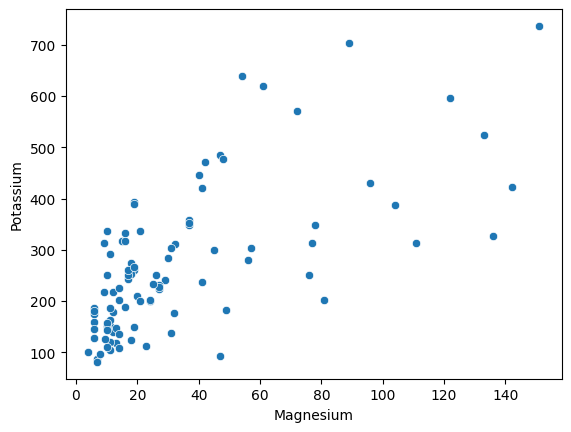

In [5]:
# visualise distribution
sns.scatterplot(data=foods, x='Magnesium', y='Potassium')

many foods have both relatively low mg and potassium values. select clusters with low, medium and high vals (low might have highest number of foods); generate df of only values

In [6]:
# nutrient splitting
nutrients = foods.iloc[:, [2,3]]
nutrients

,Magnesium,Potassium
0,122.0,597.0
1,77.0,314.0
2,151.0,737.0
3,20.0,210.0
4,13.0,117.0
...,...,...
91,10.0,144.0
92,9.5,126.0
93,7.0,81.0
94,40.0,446.0


### K-Means Modelling

- cluster with elbow analysis and silhouette score to determine suitable number of clusters

In [7]:
# normalise nutrient values
scaler = StandardScaler()
nutrients = scaler.fit_transform(nutrients)
nutrients

array([[ 2.61587568e+00,  2.33064753e+00],
       [ 1.27982785e+00,  3.29592634e-01],
       [ 3.47688427e+00,  3.32056869e+00],
       [-4.12499386e-01, -4.05777365e-01],
       [-6.20329048e-01, -1.06336785e+00],
       [ 2.10989597e-01,  1.08617523e+00],
       [-2.93739580e-01, -4.76486019e-01],
       [-3.82809435e-01,  4.85151672e-01],
       [-4.78293287e-02,  3.09609753e-01],
       [-6.79708951e-01, -8.22958422e-01],
       [-4.71879290e-01,  5.38288841e-02],
       [-7.09398902e-01, -1.22942750e-01],
       [-8.28158709e-01, -9.85588326e-01],
       [-7.39088854e-01, -3.56281308e-01],
       [-1.45289822e-01, -1.86580539e-01],
       [-4.71879290e-01, -1.02094265e+00],
       [-2.04669725e-01, -3.13856115e-01],
       [-7.39088854e-01,  3.22521768e-01],
       [-8.28158709e-01, -7.66391499e-01],
       [-7.09398902e-01,  4.85151672e-01],
       [-7.09398902e-01, -8.22958422e-01],
       [-7.98468757e-01, -1.27549381e+00],
       [-6.79708951e-01, -7.45178903e-01],
       [-7.

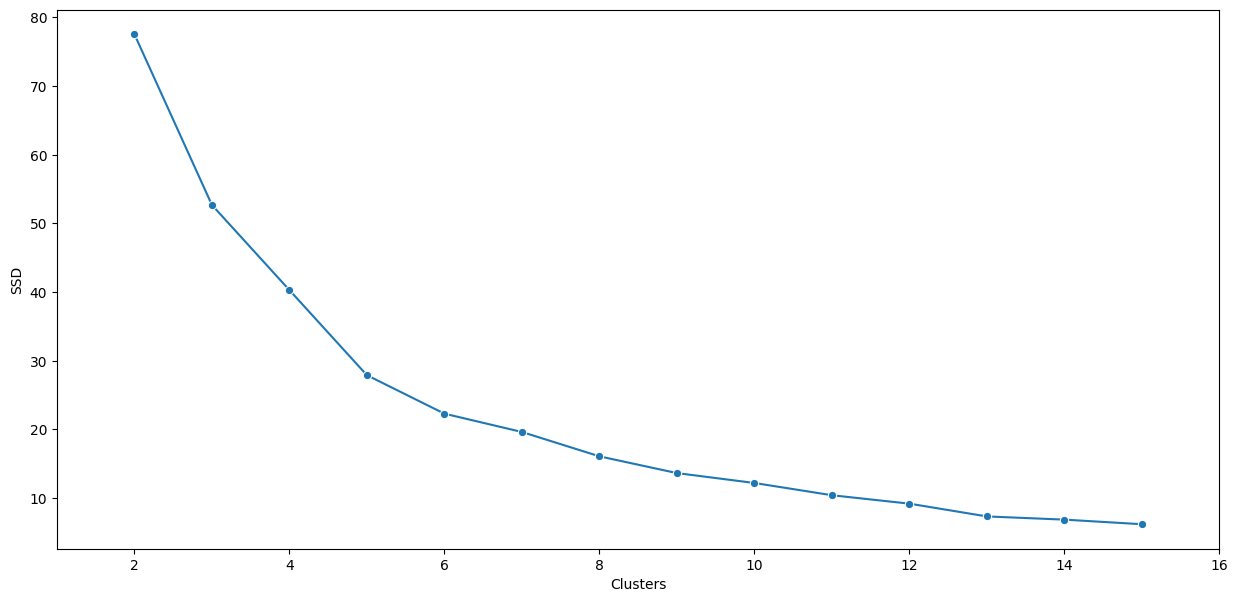

In [8]:
clusters = list(range(2,16)) # test clusters from 2 to 15
ssd = [] # sum of squared distances

for k in clusters:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    km.fit(nutrients)
    ssd.append(km.inertia_)

# elbow plot
plt.figure(figsize=(15,7))
ax = sns.lineplot(x=clusters, y=ssd, marker="o", dashes=False)
ax.set_xlabel('Clusters')
ax.set_ylabel('SSD')
ax.set(xlim=(1,16))
plt.plot();

- elboow point at 6/7

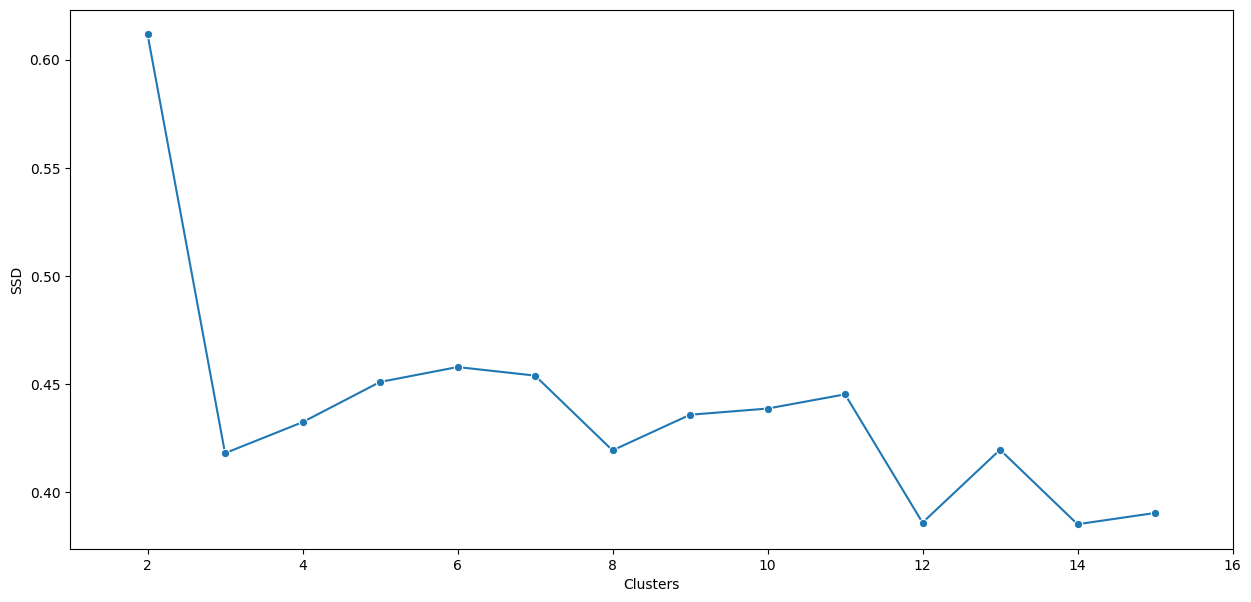

In [9]:
# silhouette score for verification
clusters = list(range(2,16)) # test clusters from 2 to 15
ssc = [] # sum of squared distances

for k in clusters:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    km.fit(nutrients)
    km_labels = km.labels_
    ssc.append(silhouette_score(nutrients, km_labels))

# elbow plot
plt.figure(figsize=(15,7))
ax = sns.lineplot(x=clusters, y=ssc, marker="o", dashes=False)
ax.set_xlabel('Clusters')
ax.set_ylabel('SSD')
ax.set(xlim=(1,16))
plt.plot();

- settled on 6 clusters. remodel with 6 clusters and set to nutrient data

In [10]:
km = KMeans(n_clusters=6, random_state=0, n_init="auto")
km.fit(nutrients)
foods['Category'] = km.labels_
foods

,Code,Vegetable,Magnesium,Potassium,Category
0,4001,"Amaranth, leaves, picked, raw",122.0,597.0,4
1,4039,"Amaranth, leaves, picked, boiled, drained (wit...",77.0,314.0,5
2,4040,"Amaranth, leaves, picked, stewed (without salt)",151.0,737.0,4
3,4002,"Bitter gourd, whole, different varieties, raw",20.0,210.0,2
4,4041,"Bitter gourd, whole, different varieties, boil...",13.0,117.0,2
...,...,...,...,...,...
91,4097,"Tomato, green, boiled, drained (without salt)",10.0,144.0,2
92,4036,"Tomato, red, ripe, raw",9.5,126.0,2
93,4098,"Tomato, red, ripe, boiled, drained (without salt)",7.0,81.0,2
94,4038,"Vine (African) spinach, picked leaves, raw",40.0,446.0,1


##### Visualise clusters

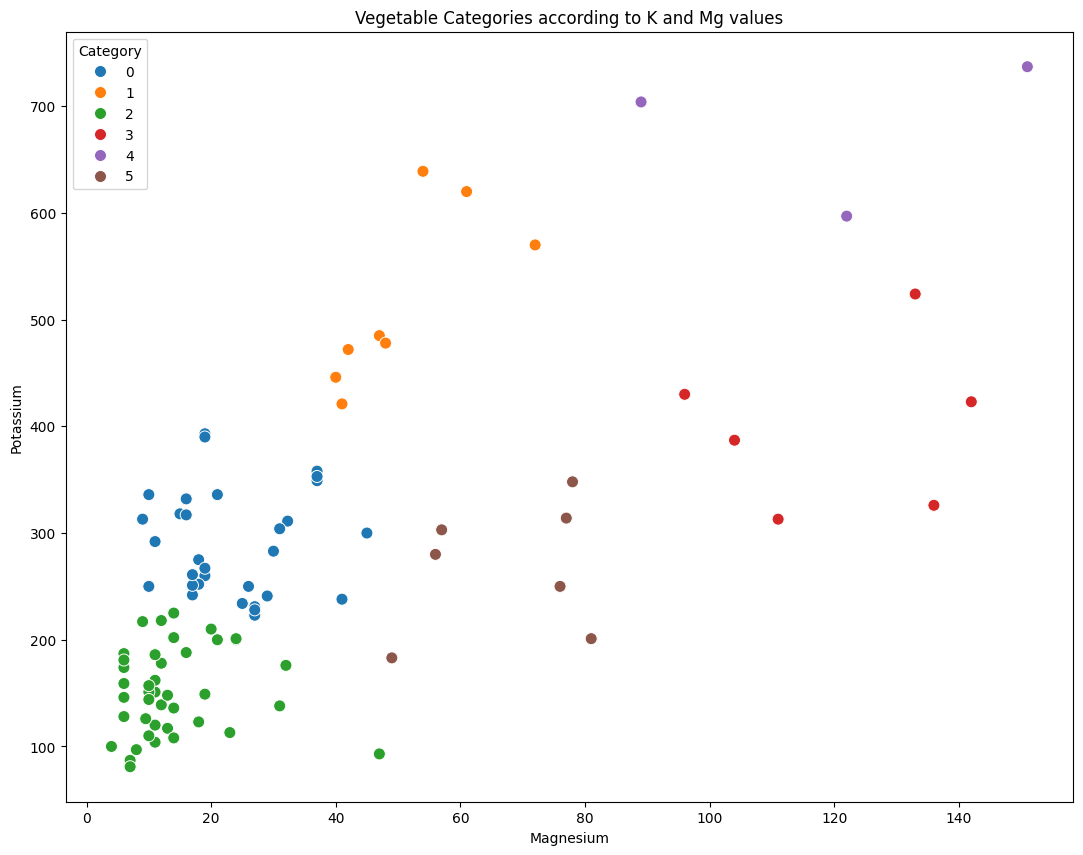

In [11]:
plt.figure(figsize=(13,10))
sns.scatterplot(data=foods, x='Magnesium', y='Potassium', hue='Category', palette="tab10", s=75)
plt.title("Vegetable Categories according to K and Mg values")
plt.legend(title='Category')
plt.show()

In [ ]:
# export to csv for use in DB and app
foods.to_csv(foods_path + '/' + 'cat_veg.csv', index=False)
foods_fn = 'models/foods_km.pkl'
pkl.dump(km, open(foods_fn, 'wb'))